# **Seminar 2 — Support Vector Machine**

1. **Part I: Data preparation & analysis**
    - The provided dataset contains features (CSI matrices) and labels (human poses), which are
split into train and test partitions. Apart from that, `SkelletonPoints` are provided to
visualize the actual pose captured with a camera. In this first part, you will have to prepare
and understand the data that you are going to use to train and evaluate your SVM. Complete
the following tasks:
        - Create a function/script that takes `SkelletonPoints` as input and plots the corre-
sponding pose. Your plotting function should also display the label associated with
the pose being plotted.
        - Now, focus on the CSI data (for instance, from `Train_features.csv`) and implement
the code for plotting the average CSI amplitude per subcarrier. Such a plot should
allow for understanding the status of the channel at a given specific moment and for a
specific subcarrier.
        - Finally, plot the distribution of the CSI amplitude across each subcarrier for each class.
        
2. **Part II: Model implementation**
    - Once the data to be used are clear, now is the time to implement the classifier based on SVM,
so that we can guess the pose of someone simply by analyzing Wi-Fi signals. In particular,
you have to:
        - Create a module that loads the training data and fits it into an SVM. You can leverage
existing libraries that implement SVMs (e.g., pytorch).
        - Generate predictions on the test dataset using the SVM trained in the previous step.
        - For evaluating the SVM, you should define one or more success rate metrics.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [155]:
TRAIN_FEATURES  = "Train_features.csv"
TRAIN_LABELS    = "Train_labels.csv"
TRAIN_SKELETON  = "Train_skelletonpoints.csv"

features = pd.read_csv(TRAIN_FEATURES, header=None).values.astype(float)
labels = pd.read_csv("Train_labels.csv", header=None).values.flatten()
skeleton = pd.read_csv(TRAIN_SKELETON, header=None)

N_SUBCARRIERS = 30
N_TX          = 3
N_RX          = 3
N_JOINTS      = 18


# **Part I: Data preparation & analysis**

## Task 1 - Skeleton Pose Plotter

**Skeleton structure** — 54 values per sample:
- Columns `0–17`  → **x-coordinates** for joints 1–18
- Columns `18–35` → **y-coordinates** for joints 1–18
- Columns `36–55` → **confidence scores** (0–1) for each joint

Joint connectivity follows the **MPII** convention (as stated in the slides).

In [156]:
CLASS_NAMES = {
    1: "Wave",
    2: "Push",
    3: "Crouch",
    4: "Sit Down",
    5: "Bend",
}

CONNECTIONS_18 = [
    (0,  1),   # Nose – Neck
    (1,  2),   # Neck – Right Shoulder
    (2,  3),   # Right Shoulder – Right Elbow
    (3,  4),   # Right Elbow – Right Wrist
    (1,  5),   # Neck – Left Shoulder
    (5,  6),   # Left Shoulder – Left Elbow
    (6,  7),   # Left Elbow – Left Wrist
    (1,  8),   # Neck – Right Hip
    (8,  9),   # Right Hip – Right Knee
    (9,  10),  # Right Knee – Right Ankle
    (1,  11),  # Neck – Left Hip
    (11, 12),  # Left Hip – Left Knee
    (12, 13),  # Left Knee – Left Ankle
    (0,  14),  # Nose – Right Eye
    (0,  15),  # Nose – Left Eye
    (14, 16),  # Right Eye – Right Ear
    (15, 17),  # Left Eye – Left Ear
    (2,  5),   # Right Shoulder – Left Shoulder
    (8,  11),  # Right Hip – Left Hip
]

In [157]:
def plot_skeleton(row, label=None, sample_idx=None, ax=None):
    x  = row.iloc[0:18].to_numpy(float)
    y  = row.iloc[18:36].to_numpy(float)
    cf = row.iloc[36:54].to_numpy(float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))

    for i, j in CONNECTIONS_18:
        if cf[i] > 0 and cf[j] > 0:
            ax.plot([y[i], y[j]], [-x[i], -x[j]], lw=2)
    ax.scatter(y[cf > 0], -x[cf > 0], s=25, color='red')
    ax.set_aspect('equal')
    if label is not None:
        title = f'Pose: {CLASS_NAMES[label]}  (label={label})'
        if sample_idx is not None:
            title += f'\nsample #{sample_idx}'
        ax.set_title(title)
    ax.axis('off')
    if ax is None:
        plt.show()

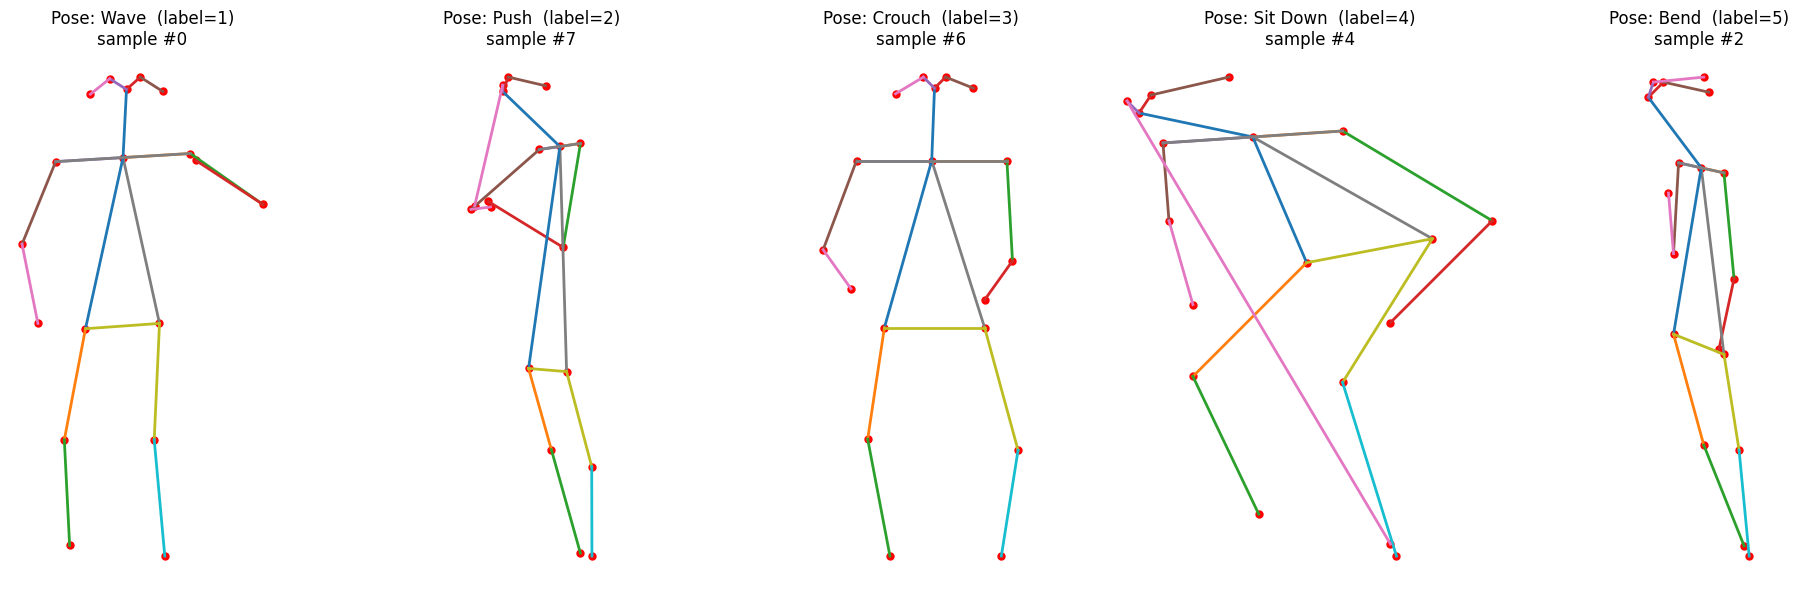

In [158]:
unique_classes = sorted(np.unique(labels))
n_classes = len(unique_classes)

fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 6))

for ax, cls in zip(axes, unique_classes):
    idx = np.where(labels == cls)[0][0]
    plot_skeleton(skeleton.iloc[idx], label=int(cls), sample_idx=idx, ax=ax)

fig.tight_layout()
plt.show()


## Task 2 - Average CSI Amplitude per Subcarrier
In this exercise we want to understand what the Wi-Fi channel looks like at a specific moment in time for a specific sample. To do this we use the CSI amplitude. 

- **CSI Amplitude**: When a Wi-Fi signal travels from the transmitter to the receiver, it is reflected, absorbed and distorted by objects in the environment, including the human body. The CSI amplitude measures how strong the received signal is at each frequency. A person standing in a certain pose will block or reflect the signal differently depending on the subcarrier frequency, creating a unique combination in the CSI.

In [159]:
def plot_avg_csi_amplitude(features, labels, sample_idx=0, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 4))

    csi = features[sample_idx].reshape(N_SUBCARRIERS, N_TX, N_RX)
    subcarriers = np.arange(1, N_SUBCARRIERS + 1)
    mean_amp = csi.mean(axis=(1, 2))

    ax.plot(subcarriers, mean_amp, label="Mean")
    cls_name = CLASS_NAMES.get(int(labels[sample_idx]))
    ax.set_title(f"CSI Amplitude per Subcarrier (sample #{sample_idx} – {cls_name})")
    ax.set_xlabel("Subcarrier")
    ax.set_ylabel("CSI Amplitude")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True)

    if standalone:
        plt.tight_layout()
        plt.show()

#### What does this plot show?

For a single sample we reshape the 270 features into `(30, 3, 3)`, 30 subcarriers × 3 TX × 3 RX, and average across the 9 antenna pairs to get one amplitude value per subcarrier. The resulting curve shows which subcarriers were well-received and which were attenuated.

This plot answers: *"What does the channel look like right now?"*, it is a snapshot of the wireless environment at the moment of one particular pose.

To test it, we call the function for a few different samples, one from each class. We tried using different samples from the same class, and we observed that even samples of the same class will show different profiles, as the exact CSI depends on the precise body position, movement, and noise. This variability is why we need a robust classifier rather than simple matching.

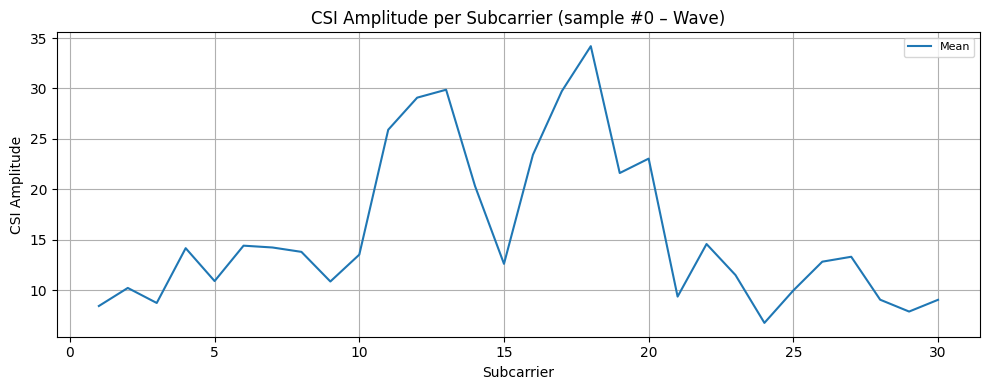

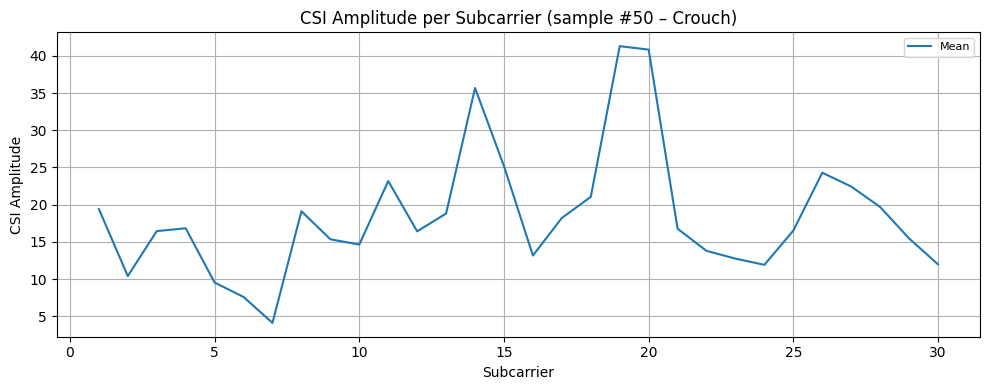

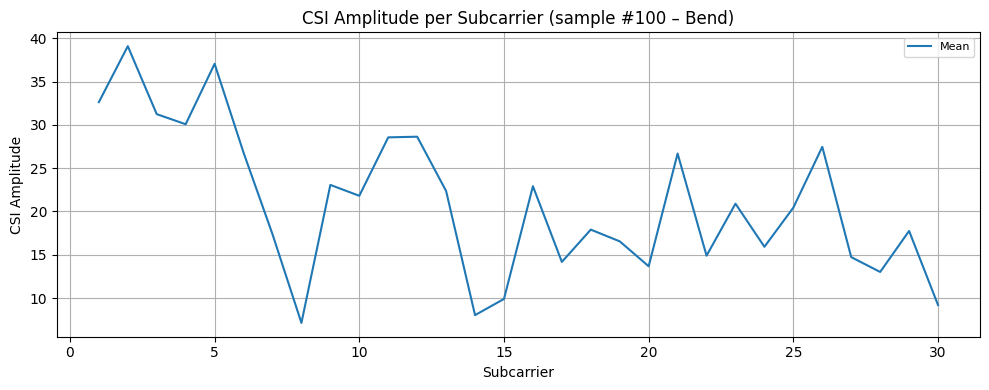

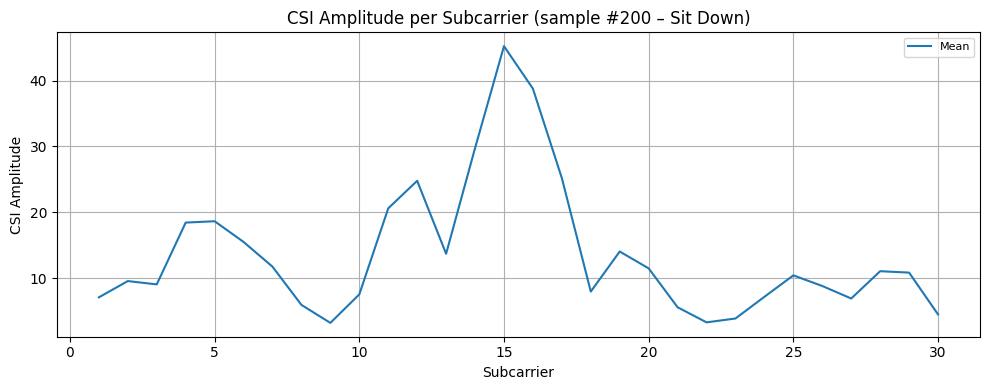

In [160]:
sample_indices = [0, 50, 100, 200] 

for ax, idx in zip(axes, sample_indices):
    plot_avg_csi_amplitude(features, labels, sample_idx=idx)


## Task 3 - CSI Amplitude Distribution per Class per Subcarrier

Rather than looking at one sample at a time, we want to understand the overall behaviour of each class across all its samples. For each class we compute the mean ± std of CSI amplitude across all samples,
averaged over the 9 antenna pairs (TX × RX).

- The **mean line** shows the typical CSI amplitude profile for that pose
- The **shaded band (±1 std)** shows how much the signal varies across different instances of the same pose

Subcarriers where the 5 classes have clearly separated mean values are the most informative features for the SVM, they help the classifier distinguish between poses. Subcarriers where all classes overlap are less useful.

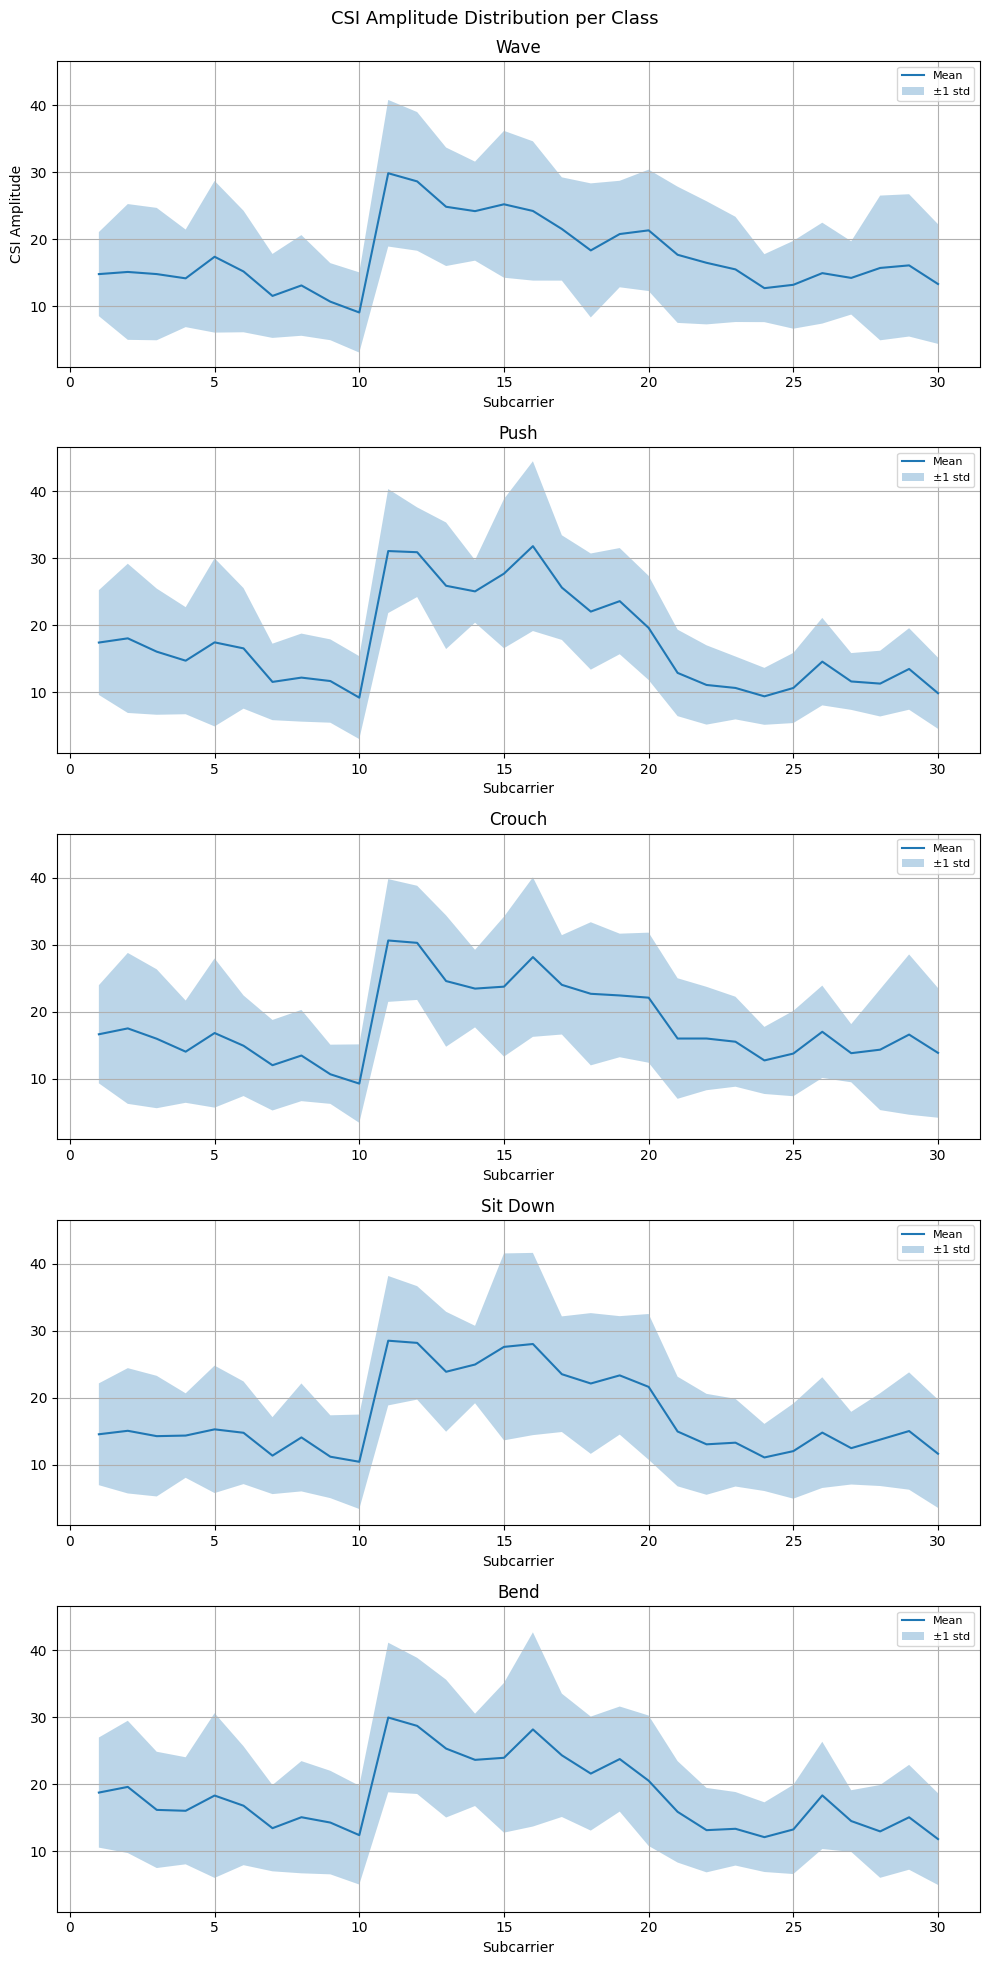

In [ ]:
unique_classes = sorted(np.unique(labels))
n_classes = len(unique_classes)
fig, axes = plt.subplots(n_classes, 1,figsize=(10, 4 * n_classes), sharey=True)

for ax, cls in zip(axes, unique_classes):
    class_samples = features[labels == cls]          
    csi = class_samples.reshape(-1, N_SUBCARRIERS, N_TX, N_RX)
    amp = csi.mean(axis=(2, 3))                      

    mean = amp.mean(axis=0)                          
    std  = amp.std(axis=0)                          
    subcarriers = np.arange(1, N_SUBCARRIERS + 1)

    ax.plot(subcarriers, mean, label='Mean')
    ax.fill_between(subcarriers, mean - std, mean + std, alpha=0.3, label='±1 std')
    ax.set_title(CLASS_NAMES[cls])
    ax.set_xlabel('Subcarrier')
    ax.grid(True)
    ax.legend(fontsize=8)

axes[0].set_ylabel('CSI Amplitude')
fig.suptitle('CSI Amplitude Distribution per Class\n', fontsize=13)
fig.tight_layout()
plt.show()

**Main observations:**

The jump at subcarrier 11 is the most obvious feature and happens for all classes, it reflects the physical environment, not the pose, so it is not useful for classification.
Subcarriers 1–10 and 11–20 are where the classes differ most, so these are where the SVM gets most of its discriminative information. Subcarriers 20–30 are less useful as all classes converge to similar values.
The wide std bands are the most important thing to notice. Within each class, the variability is almost as large as the mean. This means two samples of the same pose can look very different in CSI, which can lead to lower classification accuracy by the model.

# **Part II: Model implementation**

Now that we have explored the data, we train a Support Vector Machine (SVM) to classify poses from CSI measurements. The SVM will learn a decision boundary in the 270-dimensional feature space that separates the 5 pose classes as well as possible.

We want to build a function $h(x) = y$ that takes a 270-dimensional CSI vector $x$ and predicts the pose label $y ∈ \{1, 2, 3, 4, 5\}$. This is a multi-class classification problem.

The key assumption is that different poses produce different CSI patterns, which we verified in Part I. If the distributions per class are sufficiently distinct, a classifier can learn to distinguish them.

A **Support Vector Machine** works by finding the hyperplane in feature space that best separates the classes with the maximum margin, the largest possible distance between the hyperplane and the nearest data points of each class (the support vectors).

SVM minimises:
$$\frac{1}{2}||\omega||^2$$
subject to: $y_i(\omega^T x_i + b) \geq 1 \quad \forall i$

where $\omega$ is the weight vector defining the hyperplane and $b$ is the bias. Maximising the margin (minimising $||\omega||^2$) improves generalisation, a wider margin means the model is less sensitive to small perturbations in the input.

### Data Loading and Preprocesssing

We load both train and test splits. The model will be trained using the training data and evaluated with the test data, which it has never seen. This gives us an estimate of how well the model generalises to new data.

SVMs are sensitive to the scale of the input features because they compute distances between points. If one feature has values in the range 0–1000 and another in 0–1, the first will dominate the distance calculation and drown out the second.

In [166]:
X_train = pd.read_csv("Train_features.csv", header=None).values.astype(float)
y_train = pd.read_csv("Train_labels.csv",   header=None).values.flatten().astype(int)

X_test  = pd.read_csv("Test_features.csv",  header=None).values.astype(float)
y_test  = pd.read_csv("Test_labels.csv",    header=None).values.flatten().astype(int)

In [167]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled  = scaler.transform(X_test)

### Training the SVM

We use `SVC` (Support Vector Classifier) from scikit-learn with its default parameters. Training fits the model to the training data, it finds the hyperplane that maximises the margin between classes while minimising classification errors.

In [172]:
clf= SVC()
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

### Evaluation

We evaluate the model using three complementary metrics:

1. **Accuracy**: the overall percentage of test samples correctly classified. Simple but can be misleading if classes are imbalanced.
$$\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{total predictions}}$$

2. **Classification report**: breaks down performance per class:
   - **Precision**: of all samples predicted as class X, what fraction actually were X? (measures false positives). $$\text{Precision}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Positives}_c}$$
   - **Recall**: of all samples that actually are class X, what fraction did we correctly identify? (measures false negatives)
   $$\text{Recall}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Negatives}_c}$$
   - **F1-score**: the harmonic mean of precision and recall, a single balanced score per class
   $$\text{F1}_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

3. **Confusion matrix**: a grid where row `i`, column `j` shows how many samples of class `i` were predicted as class `j`. The diagonal is correct predictions, entries outside the diagonal reveal which classes get confused with each other.

Accuracy: 77.0%

Classification Report:
              precision    recall  f1-score   support

        Wave       0.84      0.76      0.80        42
        Push       0.71      0.82      0.76        39
      Crouch       0.78      0.89      0.83        35
    Sit Down       0.84      0.68      0.75        38
        Bend       0.72      0.72      0.72        46

    accuracy                           0.77       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200


Confusion matrix:


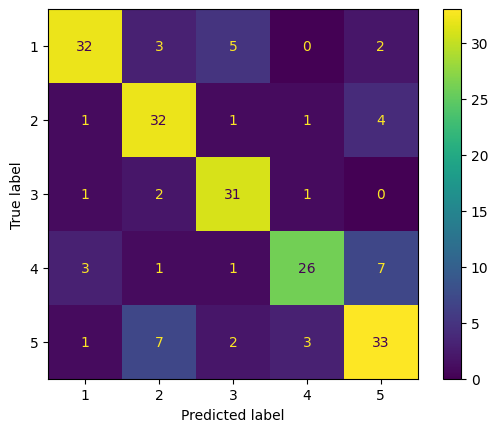

In [ ]:
# 1. Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100}%")

# 2. Precision, recall and F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_NAMES[c] for c in sorted(CLASS_NAMES)]))

# 3. Confusion matrix
print ("\nConfusion matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
disp.plot()
plt.show()

### Result analysis
The model achieves 77% accuracy on 200 test samples, which is a solid baseline for a 5-class problem, if we random guessed it would only give 20%. The F1 macro-average of 0.77 confirms the consistent performance across classes.

By analyzing class per class, we observe that:

- Crouch (class 3), best performing (F1 = 0.83)

    - Highest recall (0.89) meaning the model correctly identifies 89% of all crouch poses
    - This makes sense given that crouching creates a very distinct body shape (low centre of mass, bent knees) that produces a unique CSI pattern unlikely to be confused with upright poses

- Wave (class 1), second best (F1 = 0.80)

    - High precision (0.84) but lower recall (0.76), looking at the confusion matrix, 5 Wave samples were misclassified as Crouch (class 3). This is the biggest error for this class.

- Push (class 2), F1 = 0.76

    - Good recall (0.82) but lower precision (0.71), meaning many other classes get misclassified as Push. Looking at the confusion matrix, 7 Bend samples were predicted as Push, this is the largest misclassification in the entire matrix.

- Sit Down (class 4), F1 = 0.75

    - Lowest recall (0.68), meaning it is the most frequently missed class. 7 out of 38 Sit Down samples were predicted as Bend (class 5). This is the most significant confusion pair in the matrix and makes physical sense, both poses involve bending the body forward.

- Bend (class 5), worst performing (F1 = 0.72)

    - Both precision and recall are low. It gets confused in both directions: 7 Bend samples are predicted as Push, and 3 Bend samples are predicted as Sit Down. Bend appears to be the hardest class, its CSI pattern overlaps with both Push (forward body movement) and Sit Down (body bending).

<br>
The model struggles where poses are physically similar (e.g. Sit Down vs Bend), which means it is learning meaningful patterns rather than random noise.